In [ ]:
from erddapy import ERDDAP
import pandas as pd
import os

from accessibility import check_endpoint
from summarize import * #json_keys, data_frame

### Interoperability Assessment of EuroArgo's "Floats data and metadata", as a dataset available on the ERDDAP server

### Endpoint

In [ ]:
endpoint = "https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats-synthetic-BGC.graph"

# The given endpoint corresponds to a single dataset on the ERDDAP server
# and consists of following components: 
# ERDDAP server: https://erddap.ifremer.fr/erddap
# protocol: tabledap
# dataset id: ArgoFloats-synthetic-BGC
# output format: graph ~ ERDDAP's GUI for plotting data from this dataset

##### Table Of Content

- [Exploring the Floats datasets on the ERDDAP server](#exploring-the-floats-datasets-on-the-erddap-server)
- [Technical interoperability](#technical-interoperability)
    - [Protocol support](#protocol-support)
    - [Data format compatibility](#data-format-compatibility) 
    - [Discovery capabilities](#discovery-capabilities) 
- [Semantic interoperability](#semantic-interoperability)
    - [Presence and richness of metadata](#presence-and-richness-of-metadata)
    - [Use of standard vocabularies](#use-of-standard-vocablaries)  
    - [Data annotations completeness](#data-annotations-completeness)

In [ ]:
# Server connection & setting dataset id:
base_url = "https://erddap.ifremer.fr/erddap"
e = ERDDAP(server=base_url,protocol="tabledap")
e.dataset_id = "ArgoFloats-synthetic-BGC"

### Exploring the Floats datasets on the ERDDAP server
Exploration of available metadata of 'ArgoFloats-synthetic-BGC' & other Floats datasets

Exploration of 'ArgoFloats-synthetic-BGC'

In [ ]:
# Data Descriptor Service
DDS_URL = f"{endpoint.removesuffix('.graph')}.dds"
print("DDS URL: ",DDS_URL)
dds_text = requests.get(DDS_URL).text
print(dds_text)

In [ ]:
# Data Access Service
DAS_URL = f"{endpoint.removesuffix('.graph')}.das"
print("DAS URL", DAS_URL)
das_text = requests.get(DAS_URL).text
print(das_text)

In [ ]:
# Metadata summary
INFO_URL = f"{base_url}/info/ArgoFloats-synthetic-BGC/index.json"
print("INFO URL", INFO_URL)
info_json = requests.get(INFO_URL).json()
info_json

In [ ]:
# WARNING THIS TAKES A LONG TIME TO RUN
# Get data (as 2D dataframe)
e.to_pandas()

In [ ]:
# WARNING THIS TAKES A LONG TIME TO RUN 
# Get data (as ncCF)
e.to_ncCF()

Exploration of other Floats datasets

In [ ]:
# Check for other datasets that represent Floats data and metadata:
e.dataset_id = "allDatasets"
all_datasets_df = e.to_pandas()
float_datasets = all_datasets_df[all_datasets_df['datasetID'].str.contains('float', case=False)]
float_datasets

In [ ]:
metadatainfo_df = pd.DataFrame(columns=["Row Type", "Variable Name", "Attribute Name", "Data Type", "Value", "DatasetID"])
# get metadata information for each dataset
for datasetID in float_datasets['datasetID']:
    e.dataset_id = datasetID
    try:
        _df = pd.read_csv(e.get_info_url(response="csv")) #metadata retrieved via info_url
        _df["DatasetID"] = 'ArgoFloats-synthetic-BGC'
        metadatainfo_df = pd.concat([metadatainfo_df, _df], ignore_index=True)
    except Exception as e:
        print(f"there was an error for {datasetID}: '{e}'")

# save to csv file
os.mkdir("files_euroargo_erddap") if not os.path.exists("files_euroargo_erddap") else None
metadatainfo_df.to_csv("files_euroargo_erddap/dataset_metadata.csv", index=False)
metadatainfo_df

### Technical interoperability

1. Protocol support = check whether standard data access protocols are supported
2. Data format compatibility = check whether standard formats are outputed
3. Metadata Standard Compliance (~ more fitting with semantic interoperability)
4. Discovery capabilities = evaluate ease of discovering datasets  
5. (Data access and subsetting)  
6. (API robustness and error handling)  
7. (performance and reliability )  

##### Protocol support

In [ ]:
#1. Endpoint availability and protocol used
if check_endpoint(endpoint):
    print("The endpoint is machine-accessible.")
else:
    print("The endpoint is not machine-accessible.")

In [ ]:
response = requests.get(endpoint)
server_headers = response.headers

tech_results = {
    # General protocol and status checks
    "General protocol and status checks" : 
        {
        "HTTP/HTTPS Protocol": endpoint.startswith("http"),
        "Status Code 200 OK": response.status_code == 200,
        },
    # Content negotiation
    "Content negotiation" : 
        {
        "MIME Type Present": "Content-Type" in server_headers,
        "MIME Type": server_headers.get("Content-Type"),
        "Content Negotiation Support": "Vary" in server_headers or "Accept" in server_headers,
        "Vary": server_headers.get("Vary"),                         # response may change depending on 'Accept-Encoding'
        "Accept-Ranges": server_headers.get("Accept-Ranges"),       # support partial content requests (e.g., 'bytes')
        },
    # Content negotiation related headers
    "Content negotiation related headers" : 
        { 
        "Content-Length": server_headers.get("Content-Length"),             # total size of the file, if specified
        "Content-Disposition": server_headers.get("Content-Disposition"),   # tells if file is inline or attachment
        "Content-Encoding": server_headers.get("Content-Encoding"),         # compression format (e.g., gzip)
        "Accept": server_headers.get("Accept"),                             # what media types the client accepts (rare in response)
        "Accept-Encoding": server_headers.get("Accept-Encoding"),           # what compression formats the client accepts (rare in response)
        },
    # Caching-related headers
    "Caching-related headers" : 
        {
        "Cache-Control": server_headers.get("Cache-Control"),       # caching policy (e.g., no-cache, max-age)
        "ETag": server_headers.get("ETag"),                         # version identifier for the file, useful for caching and validation
        }
}

# Output the results
tech_results

##### Data format compatibility
*check whether standard formats are outputed*

this information is available in the documentation:  
```https://erddap.ifremer.fr/erddap/tabledap/documentation.html```

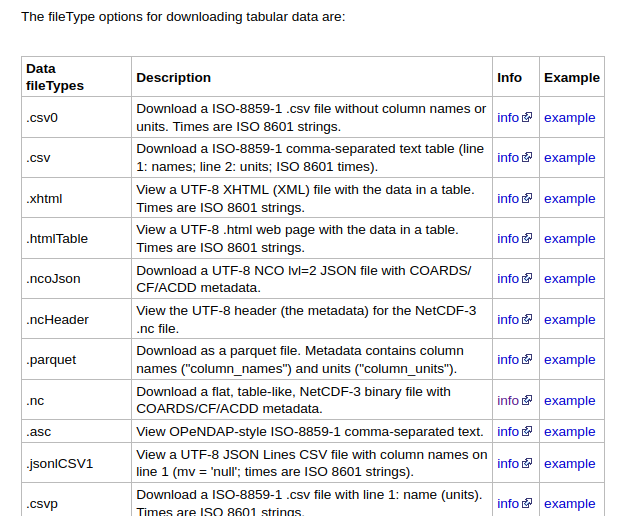  
--> there are many download formats available, o.a. many standard (open) formats (e.g. CSV, JSON, NetCDF, ...)



##### Discovery capabilities

In [ ]:
#to-do

### Semantic interoperability

#### Presence and richness of metadata
*Involves checking availability and completeness of descriptive metadata, global metadata presence and if standard metadata fields are populated (e.g., `title`, `summary`, `institution`, `keywords`)*  


In [ ]:
#to-do

#### Use of standard vocabularies  
*Involves checking whether terms/properties follow standard vocabularies (e.g., NERC, CF, GCMD)*  

In [ ]:
#to-do

#### Data annotation completeness 
*Involves checking accuracy and presence of descriptivle variables, e.g. whether they have `long_name`, `units`, `standard_name`, `coverage_content_type`*


In [ ]:
#to-do

# OLD STUFF

In [ ]:
# analysed endpoint: 
endpoint_url = "https://erddap.ifremer.fr/erddap"

#connect to server
argoERDDAP = ERDDAP(server=endpoint,protocol="tabledap")

In [ ]:
if check_endpoint(endpoint):
    print("The endpoint is machine-accessible.")
else:
    print("The endpoint is not machine-accessible.")

**Exploration of the allDatasets dataset**  
~ retrieving a dataset that lists all available datasets on the ERDDAP server. The returned DataFrame will contain metadata for each dataset available on that server  
~ essentially a catalog of all datasets hosted on the server, including essential metadata that allows you to identify and filter the datasets of interest  

In [ ]:
#Set a dataset ID
argoERDDAP.dataset_id = "allDatasets"

#Get data (as 2D dataframe)
argoERDDAP_allDatasets_df = argoERDDAP.to_pandas()

In [ ]:
#explore columns
argoERDDAP_allDatasets_df.columns

In [ ]:
# save
argoERDDAP_allDatasets_df.to_csv("files_euroargo_erddap/overview_metadata.csv", index=False)
#view 
argoERDDAP_allDatasets_df

In [ ]:
# other metadata (~written metadata, intended for human reading?) available with df.summary
argoERDDAP_allDatasets_df.summary

Exploration of **search information** for each data offered through the ERDDAP server

In [ ]:
# get search information
searchinfo_df = pd.read_csv(argoERDDAP.get_search_url(response="csv"))

In [ ]:
searchinfo_df.columns

In [ ]:
searchinfo_df

Exploration of **metadata** available for each dataset offered through the ERDDAP server

In [ ]:
# Metadata information for each dataset
metadatainfo_df = pd.DataFrame(columns=["Row Type", "Variable Name", "Attribute Name", "Data Type", "Value", "DatasetID"])
# get metadata for each dataset
for datasetID in argoERDDAP_allDatasets_df['datasetID']:
    argoERDDAP.dataset_id = datasetID
    try:
        _df = pd.read_csv(argoERDDAP.get_info_url(response="csv")) #metadata retrieved via info_url
        _df["DatasetID"] = datasetID
        metadatainfo_df = pd.concat([metadatainfo_df, _df], ignore_index=True)
    except Exception as e:
        print(f"there was an error for {datasetID}: '{e}'")
        continue

# save to csv file
os.mkdir("files_euroargo_erddap") if not os.path.exists("files_euroargo_erddap") else None
metadatainfo_df.to_csv("files_euroargo_erddap/all_dataset_metadata.csv", index=False)
# view
metadatainfo_df

In [ ]:
# explore returned metadata
metadatainfo_df.groupby(['DatasetID', 'Row Type']).nunique()

In [ ]:
# Explore the dimensions of each dataset (Row Type = 'dimension')
dim_info = metadatainfo_df[ metadatainfo_df['Row Type'] == 'dimension'].groupby(['DatasetID', 'Variable Name']).agg({
        'Data Type': 'unique',
        'Value': 'unique'
    }).reset_index()

dim_info.to_csv("files_euroargo_erddap/dataset_metadata_dimensions.csv", index=False)

dim_info

In [ ]:
# Explore the variables of each dataset (Row Type = 'variable')
#note: in netCDFs, attributes represent additional information 
var_info = metadatainfo_df[ metadatainfo_df['Row Type'] == 'variable'].groupby(['DatasetID', 'Variable Name']).agg({
        'Data Type': 'unique',
        'Value': 'unique'
    }).reset_index()

var_info.to_csv("files_euroargo_erddap/dataset_metadata_variables.csv", index=False)

var_info

In [ ]:
# Explore the attributes of each dataset (Row Type = 'attribute')
metadatainfo_df[ metadatainfo_df['Row Type'] == 'attribute'].groupby(['DatasetID', 'Attribute Name']).nunique()

In [ ]:
# and the variables/dimensions with which they're associated 
attr_info = metadatainfo_df[ metadatainfo_df['Row Type'] == 'attribute'].groupby(['DatasetID', 'Attribute Name', 'Variable Name']).agg({
        'Data Type': 'unique',
        'Value': 'unique'
    }).reset_index()

attr_info.to_csv("files_euroargo_erddap/dataset_metadata_attributes.csv", index=False)

attr_info

Exploration of **data** available for each dataset offered through the ERDDAP server, by accessing as pd.DataFrame  
(less efficient than accessing as ncCF)

In [ ]:
#list datasets
print(f"there are {len(argoERDDAP_allDatasets_df['datasetID'].drop_duplicates())} datasets available via ARGO ERDDAP")

# Connect to server 
erddap = ERDDAP(server="https://erddap.ifremer.fr/erddap", protocol="tabledap")

df_summary_full = pd.DataFrame(columns=["DatasetID", "Property", "Count", "Types", "Example"])
#first half (otherwise code takes too long to run)
for datasetID in argoERDDAP_allDatasets_df['datasetID'][:len(argoERDDAP_allDatasets_df) // 2]:
    print(f"Processing dataset: {datasetID}")
    
    try:
        # Set the dataset ID
        erddap.dataset_id = datasetID
        
        # Fetch data as a 2D dataframe with timeout handling
        dataset_df = erddap.to_pandas()
        
        # Process data        
        df_summary = data_frame(dataset_df, datasetID)
        df_summary_full = pd.concat([df_summary_full, df_summary], ignore_index=True)
        df_summary_full.to_csv("files_euroargo_erddap/dataset_data.csv", index=False)
    except Exception as e:
        print(f"There was an error for {datasetID}: {e}")

df_summary_full

#Property ~ variables (attributes & dimensions not clear)

Extra step needed to retrieve actual data

In [ ]:
#Set a dataset ID
argoERDDAP.dataset_id = "ArgoFloats-reference"

#Get data (as 2D dataframe)
argoERDDAP_ArgoFloats_reference_df = argoERDDAP.to_pandas()
argoERDDAP_ArgoFloats_reference_df

### Analysis results:

- requires knowledge on ERDDAP servers & netCDF file format  
- ERDDAP server offers 52 datasets  
- mainly NetCDF data
- exploration of 'ARGO_ERDDAP_dataset_data.csv' and 'ARGO_ERDAP_dataset_metadata.csv' (which shows information about the properties in each datasets (such as type, example, unique values, ...)) shows:
    - All data is findable, not always accessible:
        - presence of 'log in' as a value of the 'accessible' column indicates that not all data is openly available.  
    - values for license property mention known, standard licenses but no use of their URLs  
    - opportunity for more use of persistent identifiers (e.g. station codes, ROR-id for institutes, ...)
- some datasets (directly) return data, while others require an additional step to retrieve the actual data:
    - for example, 'ArgoFloats' dataset contains file paths in 'file' column
    - 'files' column in 'ARGO_ERDDAP_overview_metadata.csv' indicates that some data is retrieved through an additional step  
    - documentation does mentions "OpenDAP on top of NetCDF files"  


